In [5]:
"""
this notebook will show simple implementations of Time Series Models, including some good ways to preprocess the data 
whereafter We will do analysis, and perform short term forecasts
"""

'\nthis notebook will show simple implementations of Time Series Models, including some good ways to preprocess the data \nwhereafter We will do analysis, and perform short term forecasts\n'

# Data Fetching & Preprocessing

In [6]:
import yfinance as yf
import pandas as pd
from typing import Union, List

In [7]:
# Functions

def fetch_stock_data_close(tickers: Union[str, List[str]], period: str = "7d", interval: str = "1m") -> pd.DataFrame:
    """
    Fetches historical stock data and isolates the 'Close' prices for modeling.

    Parameters:
    -----------
    tickers : str or list of str
        The stock ticker symbol(s) to fetch. Examples: "AAPL" or ["TSLA", "NVDA"].
    period : str
        The time period to download data for. 
        Valid options: "1d", "5d", "1mo", "3mo", "6mo", "1y", "2y", "5y", "10y", "ytd", "max".
    interval : str
        The frequency of the data points. 
        Valid options: "1m", "2m", "5m", "15m", "30m", "60m", "90m", "1h", "1d", "5d", "1wk", "1mo", "3mo".
        Note: "1m" data is heavily restricted by Yahoo Finance and only available for the last 7 days.

    Returns:
    --------
    pd.DataFrame
        A clean DataFrame containing only the closing prices for the requested tickers,
        indexed by datetime. 
    """
    # Standardize input: convert a single string to a list so the logic below always works
    if isinstance(tickers, str):
        tickers = [tickers]

    print(f"Fetching {interval} data for {tickers} over the last {period}...")
    
    # Download data. By default, yfinance puts 'Close', 'Open', etc. at the top level
    data = yf.download(tickers, period=period, interval=interval)
    
    # Dynamically extract 'Close' prices based on the number of tickers provided
    if len(tickers) == 1:
        close_prices = data[['Close']].copy()
        close_prices.columns = [f"{tickers[0]}_Close"]
    else:
        close_prices = data['Close'].copy()
        # Dynamically rename columns to explicitly show they are close prices
        close_prices.columns = [f"{ticker}_Close" for ticker in close_prices.columns]
        
    # Drop rows with missing values to ensure a clean dataset
    close_prices.dropna(inplace=True)
    
    return close_prices


In [8]:
target_stocks = ["TSLA","NVDA"]
my_stocks_daily = fetch_stock_data_close(tickers=target_stocks, period="5y", interval="1d")

Fetching 1d data for ['TSLA', 'NVDA'] over the last 5y...


[*********************100%***********************]  2 of 2 completed


In [9]:
my_stocks_daily

,NVDA_Close,TSLA_Close
Date,,
2021-04-12,15.170764,233.993332
2021-04-13,15.640078,254.106674
2021-04-14,15.238591,244.076660
2021-04-15,16.096684,246.283340
2021-04-16,15.872493,246.593338
...,...,...
2026-04-06,177.639999,352.820007
2026-04-07,178.100006,346.649994
2026-04-08,182.080002,343.250000


In [10]:
import seaborn as sns

<Axes: xlabel='Date'>

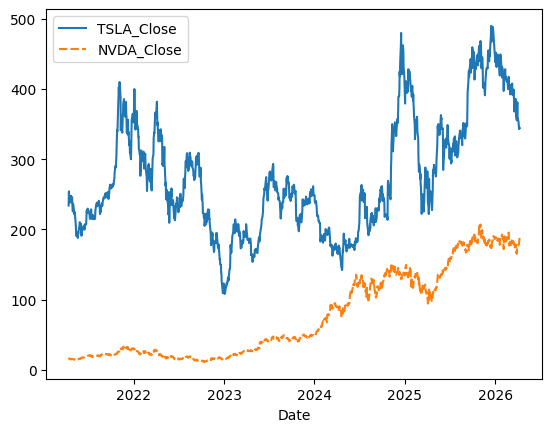

In [14]:
sns.lineplot(data = my_stocks_daily[["TSLA_Close","NVDA_Close"]])

# Pre flight checks